# Two coupled $0$-$\pi$: $n_{\theta 1}\otimes n_{\theta 2}$

### 1. Define variable transform

$1->\phi_1, 2->\theta_1, 3->\chi_1, 4->\Sigma_1$

$5->\phi_2, 6->\theta_2, 7->\chi_2, 8->\Sigma_2$

$9->\varphi_9, 10->Ground$

In [ ]:
# import  os
# num_cores = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = num_cores
# os.environ["OMP_NUM_THREADS"] = num_cores
# os.environ["MKL_NUM_THREADS"] = num_cores

In [ ]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting

### 2. Get circuit Hamiltonian

EC_theta = 0.092,   EC_phi = 1.142,   

EC = 1. / (0.5/EC_theta - 0.5/EC_phi) = 0.20012190476190478

Ec0=0.275  -->  g=0.0922

In [3]:
zp = scq.Circuit(ut.zp_yml, from_file=False)
zp.configure(transformation_matrix=np.linalg.inv(ut.transform_2zeropi))
zp.sym_hamiltonian()
print(zp.var_categories)
print(zp.cutoff_names)
zp.Ec0

<IPython.core.display.Latex object>

{'periodic': [2, 6], 'extended': [1, 3, 5, 7], 'free': [4, 8, 9], 'frozen': [], 'sigma': []}
['cutoff_n_2', 'cutoff_n_6', 'cutoff_ext_1', 'cutoff_ext_3', 'cutoff_ext_5', 'cutoff_ext_7']


1.0

### 3. Construct subsystem, calculate eigenvalues

In [4]:
trunc_dim = 10
system_hierarchy = [[1,2],  [5,6]]
subsystem_trunc_dims = [trunc_dim, trunc_dim]
zp.configure(system_hierarchy=system_hierarchy, subsystem_trunc_dims=subsystem_trunc_dims)

zp.cutoff_ext_1 = 100
zp.cutoff_n_2 = 30
zp.cutoff_ext_5 = 100
zp.cutoff_n_6 = 30

eval0, eket0 = zp.subsystems[0].eigensys(evals_count=trunc_dim)
eval1, eket1 = zp.subsystems[1].eigensys(evals_count=trunc_dim)
eval0 = eval0 - eval0[0]
eval1 = eval1 - eval1[0]
eket0 = ssp.csr_matrix([eket0[:,idx] for idx in range(trunc_dim)])
eket1 = ssp.csr_matrix([eket1[:,idx] for idx in range(trunc_dim)])

print(np.shape(eket1))
# zp.subsystems[0].n2_operator()
zp.sym_interaction((1,0))  # show coupling terms between subsystems 0 and 1
zp.sym_hamiltonian(subsystem_index=0)
zp.sym_hamiltonian(subsystem_index=1)
# print( zp.subsystems[0].ng2, '  ', zp.subsystems[1].ng6)
# print( zp.subsystems[0].external_flux_values(), '  ', zp.subsystems[1].external_flux_values())

(10, 6100)


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Compare the phases of two ground states from two zero-pi

In [5]:
phase_0 = np.angle(eket0[0].toarray().flatten())
phase_0 = phase_0 - phase_0[0]
phase_1 = np.angle(eket1[0].toarray().flatten())
phase_1 = phase_1 - phase_1[0]

truc = 10
print(f'phase_0: {phase_0[:truc]}')
print(f'phase_1: {phase_1[:truc]}')
print(f'phase_0 == phase_1 ? : {(phase_0 == phase_1) [:truc]}')

phase_0: [ 0.          0.          0.         -3.14159265 -3.14159265 -3.14159265
 -3.14159265 -3.14159265 -3.14159265 -3.14159265]
phase_1: [0.         3.14159265 0.         0.         3.14159265 3.14159265
 3.14159265 3.14159265 0.         3.14159265]
phase_0 == phase_1 ? : [ True False  True False False False False False False False]


### 4. Sort bare system eigenvalues, get dressed index

In [6]:
eval_bare_1d = []
order_1d = []
for idx, val0 in enumerate(eval0):
    for jdx, val1 in enumerate(eval1):
        eval_bare_1d.append(val0 + val1)
        order_1d.append(str(idx) + str(jdx))
eval_bare_2d = np.reshape(eval_bare_1d, (trunc_dim, trunc_dim) )
order_2d = np.reshape(order_1d, (trunc_dim, trunc_dim) )

sort_idx = np.argsort(eval_bare_1d)
eval_bare_sort = np.sort(eval_bare_1d)
order_sort = [order_1d[i] for i in sort_idx]
print(order_sort[:100])
print(eval_bare_sort[:trunc_dim])

['00', '01', '10', '02', '03', '20', '30', '04', '11', '40', '05', '06', '21', '31', '50', '60', '12', '13', '07', '70', '08', '22', '32', '23', '33', '14', '80', '41', '09', '24', '34', '90', '15', '16', '51', '61', '42', '43', '17', '71', '25', '35', '26', '36', '18', '52', '53', '62', '63', '27', '37', '81', '44', '72', '73', '28', '38', '19', '91', '54', '64', '82', '83', '45', '46', '47', '74', '29', '39', '92', '93', '55', '65', '56', '66', '48', '84', '57', '67', '75', '76', '77', '58', '68', '49', '94', '85', '86', '78', '87', '59', '69', '95', '96', '88', '79', '97', '98', '89', '99']
[0.         2.42796084 2.57833619 3.43468205 3.43600949 3.46860175
 3.46925132 4.71843782 5.00629703 5.02328691]


### 5. Get total Hamiltonian in dressed basis

In [7]:
index_trunc = [0, 2, 5]
eket0_trunc = []
H0 = []
for i in index_trunc:
    eket0_trunc.append(eket0[i])
    H0.append(eval0[i])
H0 = np.diag(H0)
H1 = np.zeros((len(index_trunc), len(index_trunc)),dtype=complex)
for idx, vec1 in enumerate(eket0_trunc):
    for jdx, vec2 in enumerate(eket0_trunc):
        H1[idx,jdx] = (vec1 @ zp.subsystems[1].hamiltonian() @ vec2.H).sum()

n_theta1 = np.zeros((len(index_trunc), len(index_trunc)),dtype=complex)
for idx, vec1 in enumerate(eket0_trunc):
    for jdx, vec2 in enumerate(eket0_trunc):
        n_theta1[idx,jdx] = (vec1 @ zp.subsystems[0].n2_operator() @ vec2.H).sum()

# n_theta2 = np.zeros((len(index_trunc), len(index_trunc)),dtype=complex)
# for idx, vec1 in enumerate(eket0_trunc):
#     for jdx, vec2 in enumerate(eket0_trunc):
#         n_theta2[idx,jdx] = (vec1 @ zp.subsystems[1].n6_operator() @ vec2.H).sum()

qt.Qobj(H0)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0.         0.         0.        ]
 [0.         3.46860175 0.        ]
 [0.         0.         5.98779296]]

In [8]:
# np.shape(zp.subsystems[1].n6_operator())
qt.tensor(qt.Qobj(n_theta1), qt.Qobj(n_theta1))

Quantum object: dims = [[3, 3], [3, 3]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.94206615e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  5.87995444e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.94206615e-05 5.87995444e-03
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  5.87995444e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.78026193e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 5.87995444e-03 1.78026193e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.94206615e-05 0.000

In [9]:
qt.Qobj(n_theta1)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[-7.31498795e-15+0.00000000e+00j  2.58309470e-15+0.00000000e+00j
  -4.40688796e-03+5.39688124e-19j]
 [ 2.58333867e-15+0.00000000e+00j  1.73320838e-15+0.00000000e+00j
  -1.33426456e+00+1.63400283e-16j]
 [-4.40688796e-03-5.39688124e-19j -1.33426456e+00-1.63400283e-16j
   9.64806356e-15+1.62045227e-33j]]

In [10]:
qt.Qobj(H1)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[-6.18599809e+00+0.00000000e+00j -4.55110387e-04+0.00000000e+00j
  -7.05873845e-16+8.56567582e-32j]
 [-4.55110387e-04+0.00000000e+00j -2.74768126e+00+0.00000000e+00j
  -2.95883769e-15+3.62313070e-31j]
 [-7.16732603e-16-8.89986164e-32j -2.44890749e-15-3.08176526e-31j
  -3.88399996e-01+1.05582231e-31j]]

In [11]:

# get the representation of the n_b operator in the dressed eigenbasis of the composite system
n_theta1 = np.zeros((trunc_dim, trunc_dim),dtype=complex)
for idx, vec1 in enumerate(eket0):
    for jdx, vec2 in enumerate(eket0):
        n_theta1[idx,jdx] = (vec1 @ zp.subsystems[0].n2_operator() @ vec2.H).toarray()

n_theta2 = np.zeros((trunc_dim, trunc_dim),dtype=complex)
for idx, vec1 in enumerate(eket1):
    for jdx, vec2 in enumerate(eket1):
        n_theta2[idx,jdx] = (vec1 @ zp.subsystems[1].n6_operator() @ vec2.H).toarray()

Hint = qt.tensor(qt.Qobj(n_theta1) , qt.Qobj(n_theta2))

n2, n6 = symbols('n2 n6')
g = zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6)
H_bare = (  qt.tensor(qt.Qobj(np.diag(eval0)),  qt.identity(trunc_dim))
          +  qt.tensor(qt.identity(trunc_dim),  qt.Qobj(np.diag(eval1))) )
Htot = g* Hint + H_bare


 /tmp/ipykernel_3240776/1397746821.py: 5DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_3240776/1397746821.py: 10

In [ ]:
### First way of diagonalization
n_eval = 11
eval_tot, eket_tot = Htot.eigenstates(eigvals=n_eval)
eval_tot = eval_tot - eval_tot[0]

# print(eval0[:trunc_dim])
# print(eval1[:trunc_dim])
# print(eval_tot[:trunc_dim])
# print(eval_tot - eval_bare_sort)

n_theta2_dress = qt.tensor(qt.identity(trunc_dim) , qt.Qobj(n_theta2))
n_theta2_dress_mat = np.zeros((n_eval, n_eval), dtype=complex)
for idx, vec1 in enumerate(eket_tot):
    for jdx, vec2 in enumerate(eket_tot):
        n_theta2_dress_mat[idx, jdx] = np.array(vec1.dag()* n_theta2_dress* vec2)[0][0]

qt.Qobj(n_theta2_dress_mat).tidyup(atol=1e-10)

Quantum object: dims = [[11], [11]], shape = (11, 11), type = oper, isherm = True
Qobj data =
[[ 0.00000000e+00  1.25219114e+00 -3.93612001e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  7.38816997e-03]
 [ 1.25219114e+00  0.00000000e+00  0.00000000e+00 -1.80653587e-02
   0.00000000e+00 -1.91441677e-04  0.00000000e+00  1.75966413e+00
  -8.59350724e-02  5.16746152e-02  0.00000000e+00]
 [-3.93612001e-01  0.00000000e+00  0.00000000e+00  5.32928275e-03
   0.00000000e+00 -4.93102542e-04  0.00000000e+00 -2.24425528e-01
   9.72003758e-01  9.28209974e-01  0.00000000e+00]
 [ 0.00000000e+00 -1.80653587e-02  5.32928275e-03  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.25754145e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000

In [42]:
eket_tot[0][:10]

<1x100 sparse matrix of type '<class 'numpy.complex128'>'
	with 100 stored elements in Compressed Sparse Row format>

In [40]:
### Second way of diagonalization
eval_tot, eket_tot = ssp.linalg.eigsh(Htot.data, k=11, which='SA', tol=1.e-10)
eval_tot, eket_tot = ut.clean_eval_eket(eval_tot, eket_tot)

n_theta2_dress = qt.tensor(qt.identity(trunc_dim) , qt.Qobj(n_theta2))
N_theta2_dress = (eket_tot @ n_theta2_dress.data @ eket_tot.conj().T).todense()

qt.Qobj(np.abs(N_theta2_dress)).tidyup(atol=1e-10)

Quantum object: dims = [[11], [11]], shape = (11, 11), type = oper, isherm = True
Qobj data =
[[0.00000000e+00 1.25219114e+00 3.93612001e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 7.38816997e-03]
 [1.25219114e+00 0.00000000e+00 0.00000000e+00 1.80653587e-02
  0.00000000e+00 1.91441677e-04 0.00000000e+00 1.75966413e+00
  8.59350724e-02 5.16746152e-02 0.00000000e+00]
 [3.93612001e-01 0.00000000e+00 0.00000000e+00 5.32928275e-03
  0.00000000e+00 4.93102542e-04 0.00000000e+00 2.24425528e-01
  9.72003758e-01 9.28209974e-01 0.00000000e+00]
 [0.00000000e+00 1.80653587e-02 5.32928275e-03 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.25754145e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.91441677e-04 4.93102542e-04

In [41]:
qt.Qobj(eket_tot.todense()[0])

Quantum object: dims = [[1], [100]], shape = (1, 100), type = bra
Qobj data =
[[ 6.81765282e-01+7.31488490e-01j -1.04931524e-15+1.09406417e-15j
  -1.50963632e-06-1.61973867e-06j  5.63366626e-18-1.80928055e-16j
   1.22261883e-04+1.31178813e-04j  9.78591095e-18+5.18465081e-17j
  -4.04992766e-18+1.57812832e-17j -4.15813338e-17+1.71800808e-17j
  -5.97330533e-18+3.26308514e-17j  3.92106666e-06+4.20704194e-06j
  -3.95036977e-15+1.79596420e-15j -7.48541065e-03-8.03134434e-03j
   6.17584637e-19+8.88368398e-18j -3.26839426e-17+8.50908608e-18j
   2.05339863e-17-1.54618520e-17j  2.62323620e-05+2.81455676e-05j
  -1.46491494e-17+5.45059191e-18j  7.82300171e-18-3.03011074e-17j
   1.42163139e-04+1.52531528e-04j  4.17630783e-18+1.46285075e-17j
  -7.80172829e-07-8.37073198e-07j -4.64178294e-19-3.92805433e-17j
   4.95398560e-09+5.31529480e-09j  1.04538675e-17+1.57322566e-17j
  -4.62974488e-07-4.96740621e-07j  1.83694663e-17+4.26086227e-18j
  -2.32513698e-18-4.86450793e-19j -1.99007002e-17-2.15721693e-18

In [33]:
eket_tot.todense().conj().T == qt.Qobj(eket_tot).dag().data

matrix([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]])

In [ ]:
print(np.shape(eket_tot), type(eket_tot))
print(np.shape(n_theta2_dress), type(n_theta2_dress))
print(np.shape(n_theta2_dress_mat), type(n_theta2_dress_mat))
# np.shape(eket_tot[0].full())

(11, 100) <class 'scipy.sparse._csr.csr_matrix'>
(100, 100) <class 'qutip.qobj.Qobj'>
(100, 100) <class 'numpy.ndarray'>


In [46]:
Htot

Quantum object: dims = [[10, 10], [10, 10]], shape = (100, 100), type = oper, isherm = True
Qobj data =
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          2.42796084  0.         ...  0.          0.
   0.        ]
 [ 0.          0.          3.43468205 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... 14.48222237  0.
   0.        ]
 [ 0.          0.          0.         ...  0.         15.10762675
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  16.11095689]]

((100,), numpy.ndarray)

In [51]:
np.column_stack((eket_tot[0].full(), eket_tot[1].full()))

array([[ 9.99939654e-01+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j, -9.50507025e-01+0.j],
       [-2.21417144e-06+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 1.79320521e-04+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  6.26768466e-05+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  4.31986920e-04+0.j],
       [ 5.75099692e-06+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  3.10310726e-01+0.j],
       [-1.09787916e-02+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j, -2.08815691e-04+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  1.47707263e-02+0.j],
       [ 3.84747942e-05+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 2.08509532e-04+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  4

In [43]:
ssp.csr_matrix(eket_tot)

TypeError: no supported conversion for types: (dtype('O'),)

In [41]:
N_theta2_dress = (eket_tot @ n_theta2_dress.data @ eket_tot.conj().T).todense()


TypeError: no supported conversion for types: (dtype('complex128'), dtype('O'))

### 6. Matrix element

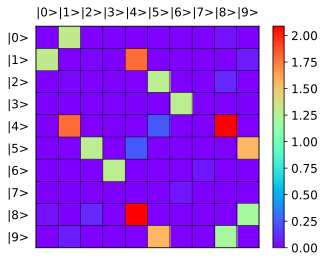

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
font_size = 15
plt.imshow(np.abs(n_theta2),aspect="auto",cmap='rainbow')
# plt.imshow(np.abs(n_theta2),aspect="auto",cmap='rainbow', norm=LogNorm(vmin = 10e-3,vmax = np.max(np.abs(n_theta2))))
# plt.title('$n_{\\theta2}$ \n$E_{C0}$=%.1f $\\to$ '%zp.Ec0 + 'g=%.4f'%g,pad=15,fontsize=font_size)
dim_plot = trunc_dim
# Major ticks
ax.set_xticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.set_yticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.xaxis.tick_top()
# Minor ticks
ax.set_xticks(np.arange(-.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-.5, 10, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
# Remove both ticks
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')


In [9]:
levels_label2 = ["00","02","20","22","05","50","25","52","55"]
level_idx = [order_sort.index(levels_label2[i]) for i in range(len(levels_label2))]
n_theta2_dress_extract = np.zeros((len(levels_label2), len(levels_label2)), dtype=complex)
for idx, level_i in enumerate(level_idx):
    for jdx, level_j in enumerate(level_idx):
        n_theta2_dress_extract[idx, jdx] = n_theta2_dress_mat[level_i, level_j]
qt.Qobj(np.round(np.abs(n_theta2_dress_extract), 3))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[0.000e+00 0.000e+00 0.000e+00 0.000e+00 7.000e-03 0.000e+00 0.000e+00
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.258e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 5.370e-01 7.000e-03
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 7.000e-03 1.239e+00
  0.000e+00 0.000e+00]
 [7.000e-03 1.258e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  1.500e-02 0.000e+00]
 [0.000e+00 0.000e+00 5.370e-01 7.000e-03 0.000e+00 0.000e+00 0.000e+00
  1.000e-03 0.000e+00]
 [0.000e+00 0.000e+00 7.000e-03 1.239e+00 0.000e+00 0.000e+00 0.000e+00
  1.000e-03 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.500e-02 1.000e-03 1.000e-03
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00]]

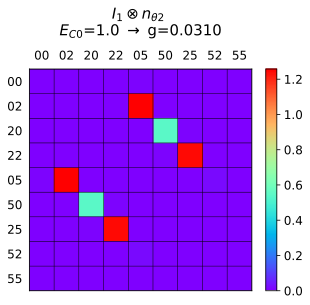

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
font_size = 15
plt.imshow(np.abs(n_theta2_dress_extract), aspect="auto", cmap='rainbow')
plt.title(r'$I_1\otimes n_{\theta 2}$ '+'\n$E_{C0}$=%.1f $\\to$ '%zp.Ec0 + 'g=%.4f'%g ,pad=15,fontsize=font_size)
ax = plt.gca();
# Major ticks
ax.set_xticks(np.arange(0, 9, 1), levels_label2)
ax.set_yticks(np.arange(0, 9, 1), levels_label2)
ax.xaxis.tick_top()
# Minor ticks
ax.set_xticks(np.arange(-.5, 9, 1), minor=True)
ax.set_yticks(np.arange(-.5, 9, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
# Remove both ticks
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()